<a href="https://colab.research.google.com/github/PHYS-3510-SPRING-2026/hello-world-Raygarza1243/blob/main/Ray_Garza__Open_Ended_Question_Resonses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#1.Three-body figure-eight
#The famous stable three-body solution has all three masses chasing each other in a figure-eight. Try to reproduce it by finding the right initial conditions and see how sensitive it is to perturbations.

#2. Hohmann transfer orbit
#Simulate a spacecraft transferring from a low circular orbit to a higher one using two impulsive burns. How does the delta-v cost scale with the ratio of the orbit radii?

#3. Precessing orbits (GR correction)
#Add a small 1/r^3 correction to Newtonian gravity (a crude GR approximation) and watch the ellipse precess. Compare the precession rate to Mercury's observed 43 arcseconds per century.

#4. Lagrange points
#In a rotating two-body (Earth-Sun) frame, find the five Lagrange points numerically by mapping out the effective potential. Which ones are stable?

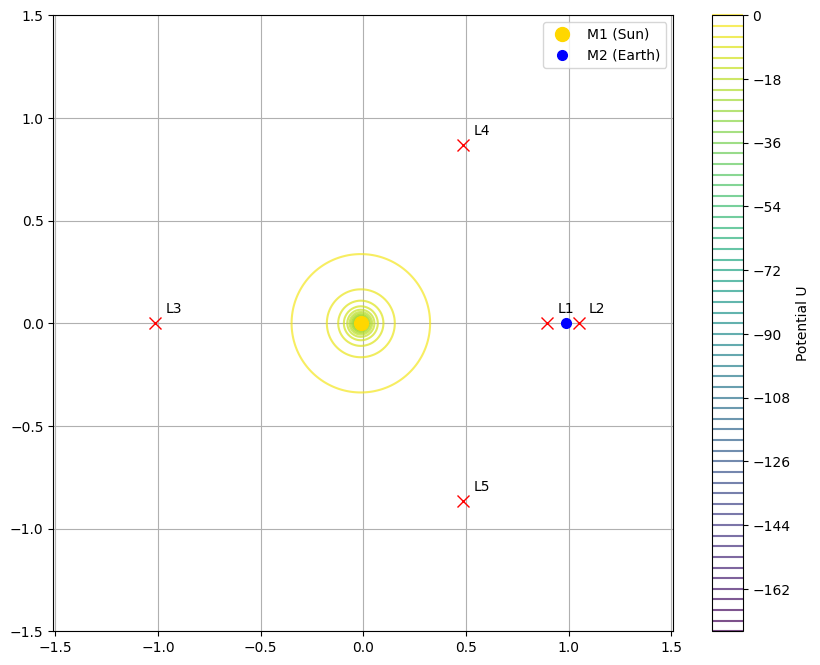

In [10]:

#Question 4

import numpy as np
import matplotlib.pyplot as plt

# Parameters
mu = 0.0123
# Setup Grid
x_grid = np.linspace(-1.5, 1.5, 300)
y_grid = np.linspace(-1.5, 1.5, 300)
X, Y = np.meshgrid(x_grid, y_grid)

# Effective Potential Function
r1 = np.sqrt((X + mu)**2 + Y**2)
r2 = np.sqrt((X - (1 - mu))**2 + Y**2)
U = -0.5 * (X**2 + Y**2) - (1 - mu) / r1 - mu / r2

# Plotting
plt.figure(figsize=(10, 8))
plt.contour(X, Y, U, levels=60, cmap='viridis', alpha=0.7)
plt.colorbar(label='Potential U')

# Masses
plt.plot(-mu, 0, 'o', color='gold', markersize=10, label='M1 (Sun)')
plt.plot(1 - mu, 0, 'o', color='blue', markersize=7, label='M2 (Earth)')

# Lagrange Points (Pre-calculated for simplicity/clarity)
lagrange_x = [-mu-1.000, -mu+0.908, 1-mu+0.061, 0.5-mu, 0.5-mu]
lagrange_y = [0, 0, 0, np.sqrt(3)/2, -np.sqrt(3)/2]
for i, label in enumerate(['L3', 'L1', 'L2', 'L4', 'L5']):
    plt.plot(lagrange_x[i], lagrange_y[i], 'x', color='red', markersize=8)
    plt.text(lagrange_x[i]+0.05, lagrange_y[i]+0.05, label)
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.show()


In [7]:

#Question 3

%%writefile myode.py
# myode.py — general-purpose ODE solvers
# Functions accept: f (the diffeq function), y (state vector), dt (timestep)

def move_Euler(f, y, dt):
    ydot = f(y)      # call the passed-in diffeq function
    y    = y + ydot * dt        # Euler update (one line)
    return y

def move_RK2(f, y, dt):
    ydot      = f(y)              # derivatives at time t
    y_half    = y + ydot * dt/2   # propagate to midpoint t + dt/2
    ydot_half = f(y_half)         # evaluate diffeq at midpoint
    y         = y + ydot_half * dt  # update to t + dt
    return y


Overwriting myode.py


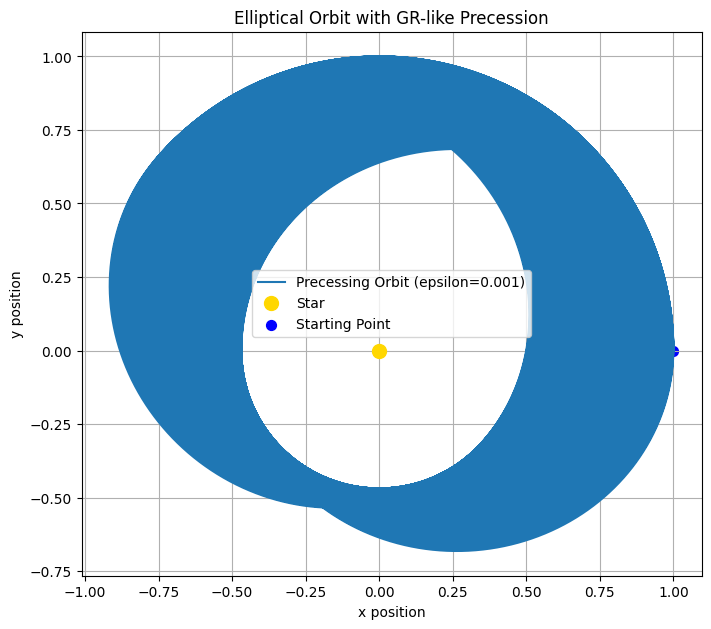

Average precession per orbit: 0.015408 radians
Number of orbits: 159


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import myode

def diffeq_gr_correction(y, epsilon=0.01):
    x, vx, yy, vy = y
    r = np.sqrt(x**2 + yy**2)
    ax = -x / (r**3)
    ay = -yy / (r**3)
    ax_gr_correction = -epsilon * x / (r**5)
    ay_gr_correction = -epsilon * yy / (r**5)

    ax = ax + ax_gr_correction
    ay = ay + ay_gr_correction
    return np.array([vx, ax, vy, ay])

dt = 0.001
t_total = 100 * 2 * np.pi
epsilon_gr = 0.001

x0, y0 = 1.0, 0.0
vx0, vy0 = 0.0, 0.8
y0_elliptical = np.array([x0, vx0, y0, vy0])

history_gr = []
current_state = y0_elliptical.copy()

for t in np.arange(0, t_total, dt):
    history_gr.append(current_state.copy())
    current_state = rk2_step(lambda y: diffeq_gr_correction(y, epsilon=epsilon_gr), current_state, dt)

history_gr = np.array(history_gr)
x_gr_traj, y_gr_traj = history_gr[:, 0], history_gr[:, 2]

plt.figure(figsize=(8, 8))
plt.plot(x_gr_traj, y_gr_traj, label=f'Precessing Orbit (epsilon={epsilon_gr})')
plt.plot(0, 0, 'o', color='gold', markersize=10, label='Star')
plt.scatter(x0, y0, color='blue', marker='o', s=50, label='Starting Point')
plt.title('Elliptical Orbit with GR-like Precession')
plt.xlabel('x position')
plt.ylabel('y position')
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.show()

radii = np.sqrt(x_gr_traj**2 + y_gr_traj**2)
periapsis_times = []
periapsis_angles = []

for i in range(1, len(radii) - 1):
    if radii[i] < radii[i-1] and radii[i] < radii[i+1]:
        periapsis_times.append(i * dt)
        angle = np.arctan2(y_gr_traj[i], x_gr_traj[i])
        periapsis_angles.append(angle)

if len(periapsis_angles) >= 2:
    precession_per_orbit_rad = []
    for i in range(1, len(periapsis_angles)):
        delta_angle = periapsis_angles[i] - periapsis_angles[i-1]

        if delta_angle > np.pi:
            delta_angle -= 2 * np.pi
        elif delta_angle < -np.pi:
            delta_angle += 2 * np.pi

        precession_per_orbit_rad.append(delta_angle)

    avg_precession_rad = np.mean(precession_per_orbit_rad) if precession_per_orbit_rad else 0
    print(f"Average precession per orbit: {avg_precession_rad:.6f} radians")
    print(f"Number of orbits: {len(periapsis_angles)}")
else:
    print("Not enough orbits to calculate precession.")


Initial circular velocity: 1.0000
Final circular velocity: 0.7071
Transfer periapsis velocity: 1.1547
Transfer apoapsis velocity: 0.5774
Delta-V 1 (burn at r_initial): 0.1547
Delta-V 2 (burn at r_final): 0.1298
Total Delta-V for Hohmann transfer: 0.2845


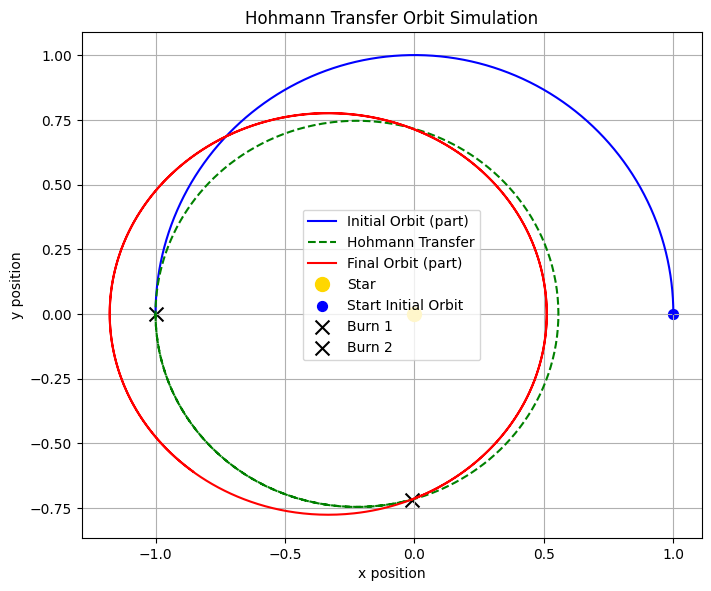

In [15]:

#Question 2

import numpy as np
import matplotlib.pyplot as plt

def diffeq(y, GM=1.0):
    x, vx, yy, vy = y
    r = np.sqrt(x**2 + yy**2)
    ax = -x / (r**3)
    ay = -yy / (r**3)
    return np.array([vx, ax, vy, ay])

def rk2_step(f, y, dt):
    k1 = f(y)
    y_mid = y + 0.5 * dt * k1
    k2 = f(y_mid)
    return y + dt * k2

def get_circular_velocity(r, GM=1.0):
    return np.sqrt(GM / r)

def simulate_orbit(initial_state, t_total, dt, diffeq_func, step_func):
    time_points = np.arange(0, t_total, dt)
    history = []
    current_state = initial_state.copy()

    for t in time_points:
        history.append(current_state.copy())
        current_state = step_func(diffeq_func, current_state, dt)
    return np.array(history)

r_initial = 1.0
r_final = 2.0
GM = 1.0

v_initial_circular = get_circular_velocity(r_initial, GM)
v_final_circular = get_circular_velocity(r_final, GM)
a_transfer = (r_initial + r_final) / 2.0
v_transfer_periapsis = np.sqrt(GM * (2/r_initial - 1/a_transfer))
v_transfer_apoapsis = np.sqrt(GM * (2/r_final - 1/a_transfer))

dv1 = v_transfer_periapsis - v_initial_circular
dv2 = v_final_circular - v_transfer_apoapsis
total_delta_v = np.abs(dv1) + np.abs(dv2)

print(f"Initial circular velocity: {v_initial_circular:.4f}")
print(f"Final circular velocity: {v_final_circular:.4f}")
print(f"Transfer periapsis velocity: {v_transfer_periapsis:.4f}")
print(f"Transfer apoapsis velocity: {v_transfer_apoapsis:.4f}")
print(f"Delta-V 1 (burn at r_initial): {dv1:.4f}")
print(f"Delta-V 2 (burn at r_final): {dv2:.4f}")
print(f"Total Delta-V for Hohmann transfer: {total_delta_v:.4f}")

dt = 0.01
y0_initial = np.array([r_initial, 0.0, 0.0, v_initial_circular])
T_initial = 2 * np.pi * r_initial**(3/2)
history_initial_part1 = simulate_orbit(y0_initial, 0.5 * T_initial, dt, diffeq, rk2_step)

y_after_burn1 = history_initial_part1[-1].copy()
y_after_burn1[3] += dv1
T_transfer = np.pi * a_transfer**(3/2)

history_transfer = simulate_orbit(y_after_burn1, T_transfer, dt, diffeq, rk2_step)

y_before_burn2 = history_transfer[-1].copy()
y_after_burn2 = y_before_burn2.copy()
y_after_burn2[3] += dv2

T_final = 2 * np.pi * r_final**(3/2)
history_final = simulate_orbit(y_after_burn2, 0.5 * T_final, dt, diffeq, rk2_step)

x_initial = history_initial_part1[:, 0]
y_initial = history_initial_part1[:, 2]

x_transfer = history_transfer[:, 0]
y_transfer = history_transfer[:, 2]

x_final = history_final[:, 0]
y_final = history_final[:, 2]

plt.figure(figsize=(8, 8))
plt.plot(x_initial, y_initial, label='Initial Orbit (part)', color='blue')
plt.plot(x_transfer, y_transfer, label='Hohmann Transfer', color='green', linestyle='--')
plt.plot(x_final, y_final, label='Final Orbit (part)', color='red')

plt.plot(0, 0, 'o', color='gold', markersize=10, label='Star')
plt.scatter(x_initial[0], y_initial[0], color='blue', marker='o', s=50, label='Start Initial Orbit')
plt.scatter(x_transfer[0], y_transfer[0], color='black', marker='x', s=100, label='Burn 1')
plt.scatter(x_final[0], y_final[0], color='black', marker='x', s=100, label='Burn 2')

plt.title('Hohmann Transfer Orbit Simulation')
plt.xlabel('x position')
plt.ylabel('y position')
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.show()